## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## Load the Dataset

In [2]:
df = pd.read_excel("Dataset.xlsx")

In [3]:
df.head()

,Product Name,Brand,Current Price,MRP,Discount_Number,Rating,Ratings,Reviews,RAM,Storage,Display,Camera,Battery,Processor,Product URL,Image URL
0,"Ai+ Nova 2 Ultra 5G (Purple, 128 GB)",ai_plus,17999.0,25999.0,30,4.1,903,88,6,128,17.22 cm (6.78 inch) Full HD+ AMOLED Display,50MP + 8MP | 13MP Front Camera,6000,Dimensity 7400 Processor,https://www.flipkart.com/ai-nova-2-ultra-5g-pu...,https://rukminim2.flixcart.com/image/312/312/x...
1,"Ai+ Pulse 1 (Blue, 64 GB)",ai_plus,7999.0,7999.0,0,4.2,43123,2831,4,64,17.13 cm (6.745 inch) HD+ Display,50MP Rear Camera | 5MP Front Camera,5000,T615 Processor,https://www.flipkart.com/ai-pulse-1-blue-64-gb...,https://rukminim2.flixcart.com/image/312/312/x...
2,"Ai+ Nova 2 Ultra 5G (Red, 128 GB)",ai_plus,19999.0,26999.0,25,4.0,413,53,8,128,17.22 cm (6.78 inch) Full HD+ AMOLED Display,50MP + 8MP | 13MP Front Camera,6000,Dimensity 7400 Processor,https://www.flipkart.com/ai-nova-2-ultra-5g-re...,https://rukminim2.flixcart.com/image/312/312/x...
3,"Ai+ Pulse 1 (Black, 64 GB)",ai_plus,7999.0,7999.0,0,4.2,43123,2831,4,64,17.13 cm (6.745 inch) HD+ Display,50MP Rear Camera | 5MP Front Camera,5000,T615 Processor,https://www.flipkart.com/ai-pulse-1-black-64-g...,https://rukminim2.flixcart.com/image/312/312/x...
4,"Ai+ Nova 2 Ultra 5G (Green, 128 GB)",ai_plus,19999.0,26999.0,25,4.0,413,53,8,128,17.22 cm (6.78 inch) Full HD+ AMOLED Display,50MP + 8MP | 13MP Front Camera,6000,Dimensity 7400 Processor,https://www.flipkart.com/ai-nova-2-ultra-5g-gr...,https://rukminim2.flixcart.com/image/312/312/x...


In [4]:
# Recommended approach
df = df[
    (df['Battery'] > 0) &  # Remove missing data
    (df['Battery'] >= 2000) &  # Remove very old/low-end phones
    (df['Current Price'] >= 5000)
].copy()

# Market Overview

In [5]:
# Number of Smartphones
print("Total Smartphones :", len(df))

Total Smartphones : 5607


In [6]:
# Number of Brands
print("Total Brands :", df["Brand"].nunique())

Total Brands : 16


In [7]:
# Smartphones by Brand
brand_count = df["Brand"].value_counts()
print(brand_count)

Brand
Samsung     1558
realme       702
Apple        437
redmi        416
Infinix      355
motorola     346
Oppo         295
vivo         256
lava         246
OnePlus      240
POCO         240
Tecno        205
IQOO         158
ai_plus       75
nothing       44
Google        34
Name: count, dtype: int64


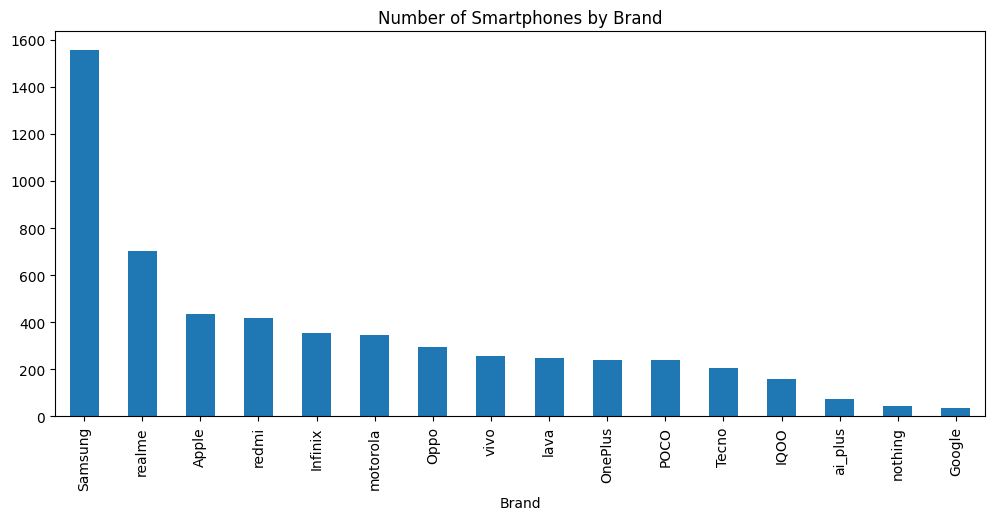

In [8]:
brand_count.plot(kind="bar", figsize=(12,5))
plt.title("Number of Smartphones by Brand")
plt.show()

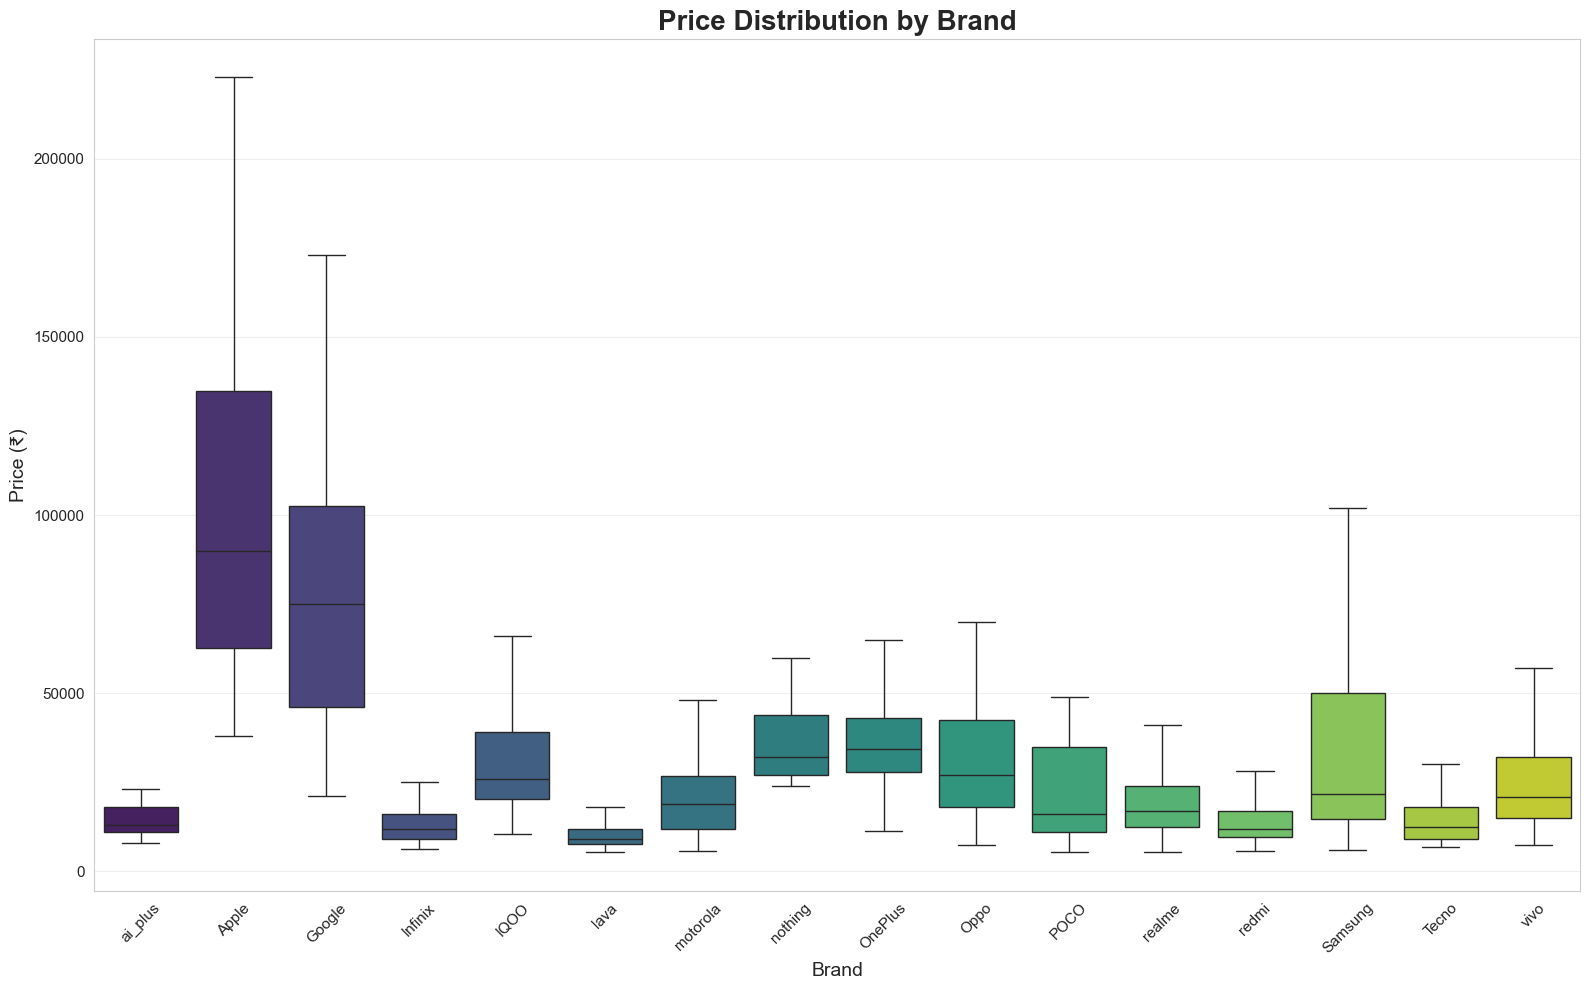

In [10]:
# Price Distribution

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create the plot with visible labels
fig, ax = plt.subplots(figsize=(16, 10))

# Box plot with proper labels
sns.boxplot(data=df, x='Brand', y='Current Price',
            hue='Brand', palette='viridis', ax=ax,
            legend=False, showfliers=False)

# Set labels with visible rotation
ax.set_title('Price Distribution by Brand', fontsize=20, fontweight='bold')
ax.set_xlabel('Brand', fontsize=14)
ax.set_ylabel('Price (₹)', fontsize=14)

# Fix: Rotate labels and ensure they're visible
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Add grid for readability
ax.grid(axis='y', alpha=0.3)

# Set y-axis limit to focus on main distribution
# ax.set_ylim(0, 200000)  # Uncomment if needed

plt.tight_layout()
plt.show()

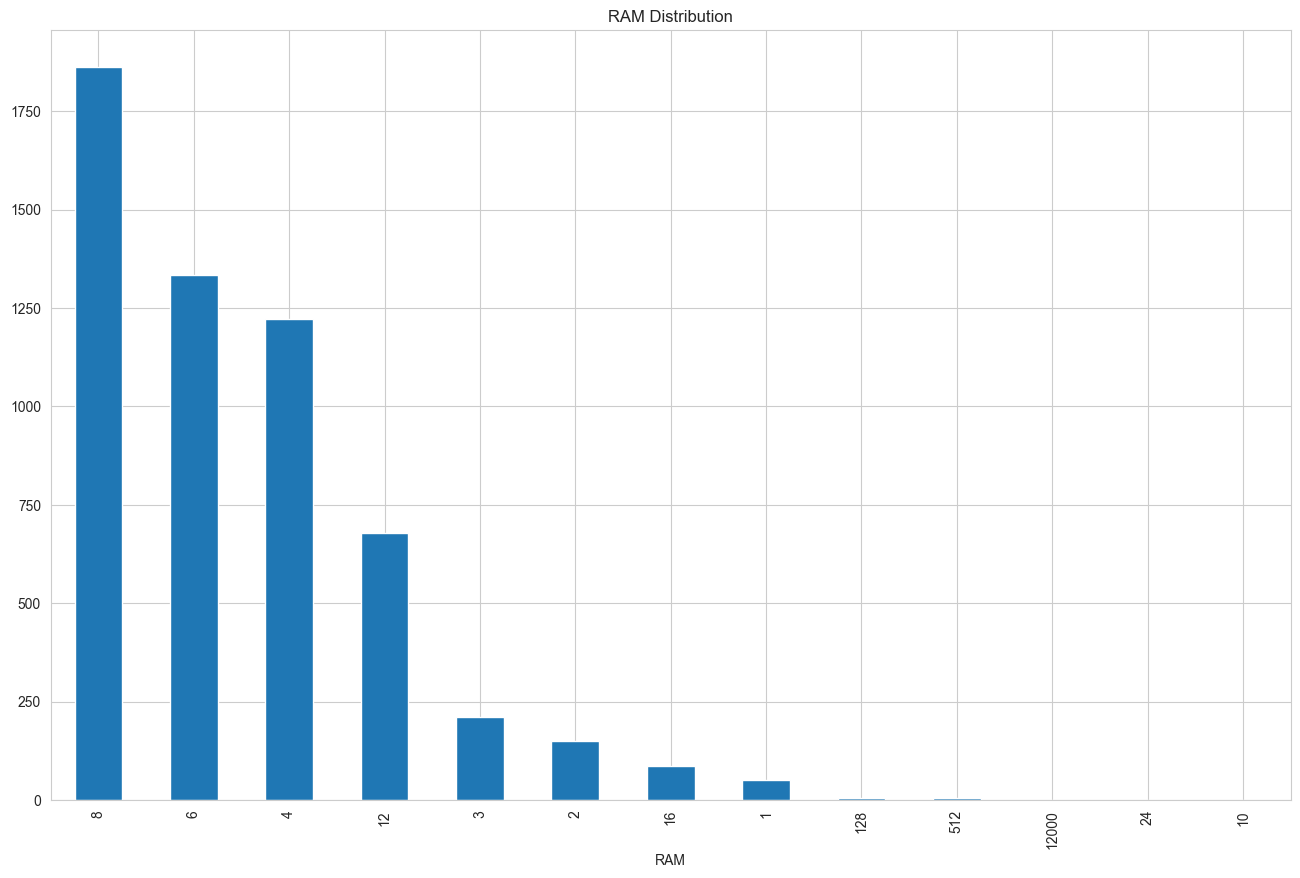

In [11]:
# RAM Distribution
ram_count = df["RAM"].value_counts()

ram_count.plot(kind="bar")
plt.title("RAM Distribution")
plt.show()

In [12]:
def extract_storage_corrected(text):
    """Extract storage in GB, handling TB correctly"""
    if pd.isna(text):
        return 0
    
    text = str(text)
    
    # Check for TB first (convert to GB)
    match_tb = re.search(r'(\d+(?:\.\d+)?)\s*TB', text, re.IGNORECASE)
    if match_tb:
        return float(match_tb.group(1)) * 1000  # Convert TB to GB
    
    # Check for GB
    match_gb = re.search(r'(\d+(?:\.\d+)?)\s*GB', text, re.IGNORECASE)
    if match_gb:
        return float(match_gb.group(1))
    
    # Check for MB (convert to GB)
    match_mb = re.search(r'(\d+(?:\.\d+)?)\s*MB', text, re.IGNORECASE)
    if match_mb:
        return float(match_mb.group(1)) / 1024
    
    return 0

# Re-apply to your dataframe
df['Storage'] = df['Product Name'].apply(extract_storage_corrected)

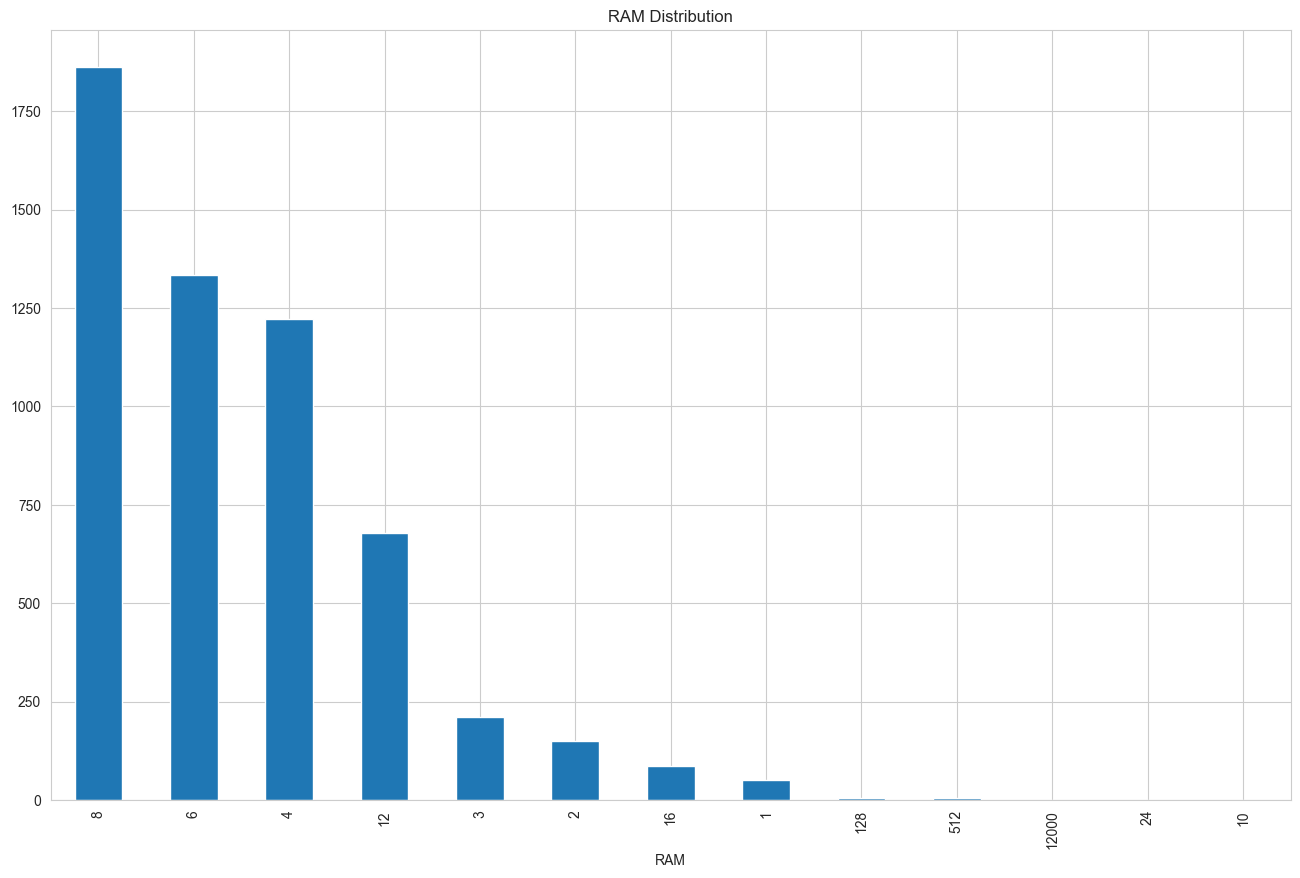

In [13]:
# RAM Distribution
ram_count = df["RAM"].value_counts()

ram_count.plot(kind="bar")
plt.title("RAM Distribution")
plt.show()

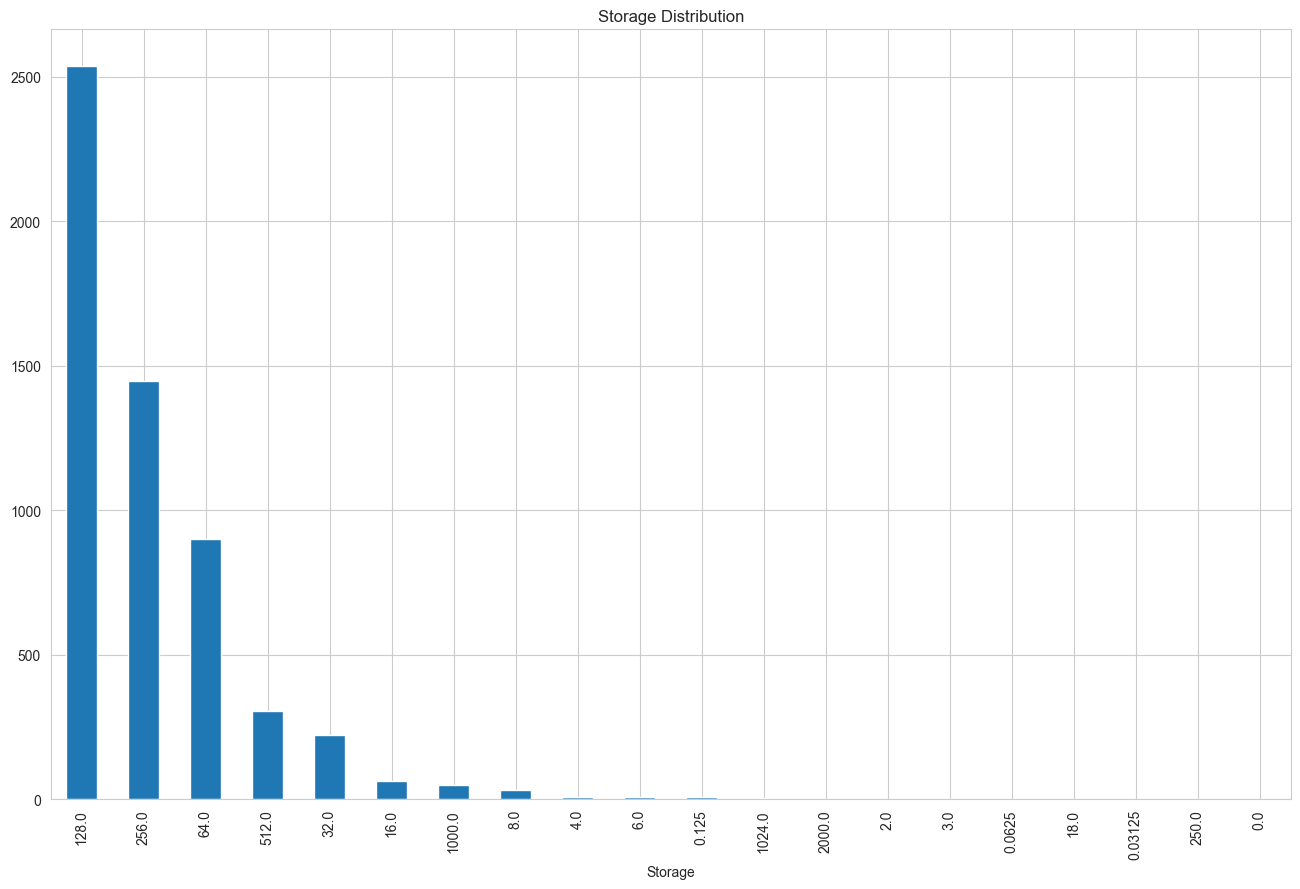

In [14]:
# Storage Distribution
storage_count = df["Storage"].value_counts()

storage_count.plot(kind="bar")
plt.title("Storage Distribution")
plt.show()

# Pricing & Product Analysis

In [15]:
# Average Price by Brand
avg_price = df.groupby("Brand")["Current Price"].mean().sort_values()

print(avg_price)

Brand
lava        10417.296748
Tecno       13868.668293
Infinix     13908.273239
redmi       14736.336538
ai_plus     14959.000000
realme      19388.215100
POCO        21377.162500
motorola    23875.835260
vivo        28033.902344
IQOO        30292.348101
Oppo        32897.993220
nothing     36726.272727
OnePlus     36819.220833
Samsung     38338.575096
Google      74534.823529
Apple       99277.313501
Name: Current Price, dtype: float64


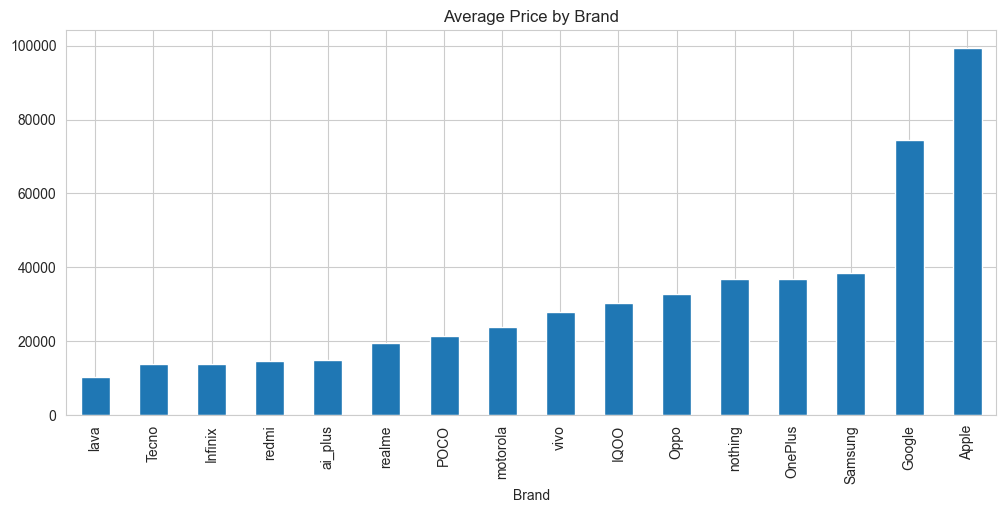

In [16]:
avg_price.plot(kind="bar", figsize=(12,5))
plt.title("Average Price by Brand")
plt.show()

In [17]:
# Average Discount
discount = df.groupby("Brand")["Discount_Number"].mean()

print(discount)

Brand
Apple        1.524027
Google       9.235294
IQOO        13.050633
Infinix     17.104225
OnePlus     16.545833
Oppo        12.566102
POCO        22.133333
Samsung     13.897946
Tecno       14.375610
ai_plus      8.026667
lava         5.292683
motorola    16.488439
nothing      7.886364
realme      13.504274
redmi       22.644231
vivo        18.414062
Name: Discount_Number, dtype: float64


In [18]:
# Top 10 Most Expensive Phones
df.nlargest(10, "Current Price")[
    ["Product Name","Brand","Current Price"]
]

,Product Name,Brand,Current Price
144,"Apple iPhone 17 Pro Max (Silver, 2 TB)",Apple,222900.0
152,"Apple iPhone 17 Pro Max (Deep Blue, 2 TB)",Apple,222900.0
473,"Apple iPhone 17 Pro Max (Cosmic Orange, 2 TB)",Apple,222900.0
4955,"Samsung Galaxy Z Fold7 5G (Jetblack, 1 TB)",Samsung,216999.0
5019,"Samsung Galaxy Z Fold7 5G (Blue Shadow, 1 TB)",Samsung,216999.0
5135,"Samsung Galaxy Z Fold7 5G (Silver Shadow, 1 TB)",Samsung,216999.0
154,"Apple iPhone 15 Pro Max (Natural Titanium, 1 TB)",Apple,199900.0
319,"Apple iPhone 15 Pro Max (Black Titanium, 1 TB)",Apple,199900.0
443,"Apple iPhone 15 Pro Max (White Titanium, 1 TB)",Apple,199900.0
492,"Apple iPhone 15 Pro Max (Blue Titanium, 1 TB)",Apple,199900.0


In [19]:
# Cheapest Phones
df.nsmallest(10,"Current Price")[
    ["Product Name","Brand","Current Price"]
]

,Product Name,Brand,Current Price
1233,"LAVA Z51 (Gold, 16 GB)",lava,5299.0
1237,"LAVA Z51 (Green, 16 GB)",lava,5299.0
1303,"LAVA Z1s (Cyan, 16 GB)",lava,5299.0
1353,"LAVA Z51 (Gold, 16 GB)",lava,5299.0
1354,"LAVA Z51 (Green, 16 GB)",lava,5299.0
2404,"POCO C50 (Royal Blue, 32 GB)",POCO,5299.0
2406,"POCO C50 (Country Green, 32 GB)",POCO,5299.0
2475,"POCO C50 (Royal Blue, 32 GB)",POCO,5299.0
2508,"POCO C50 (Country Green, 32 GB)",POCO,5299.0
2870,"realme C12 (Power Silver, 32 GB)",realme,5300.0


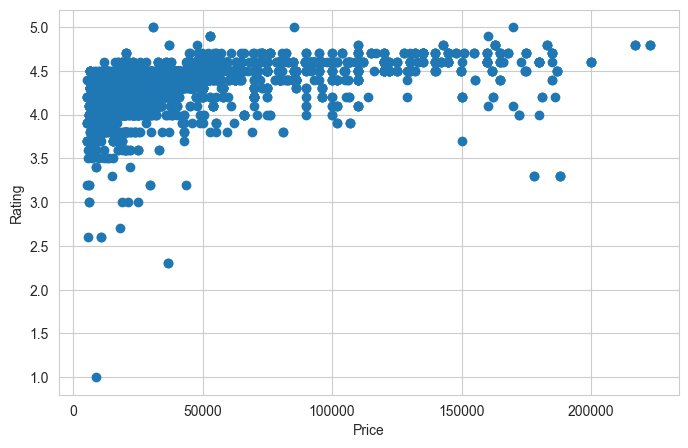

In [20]:
# Price vs Rating
plt.figure(figsize=(8,5))

plt.scatter(df["Current Price"],df["Rating"])

plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

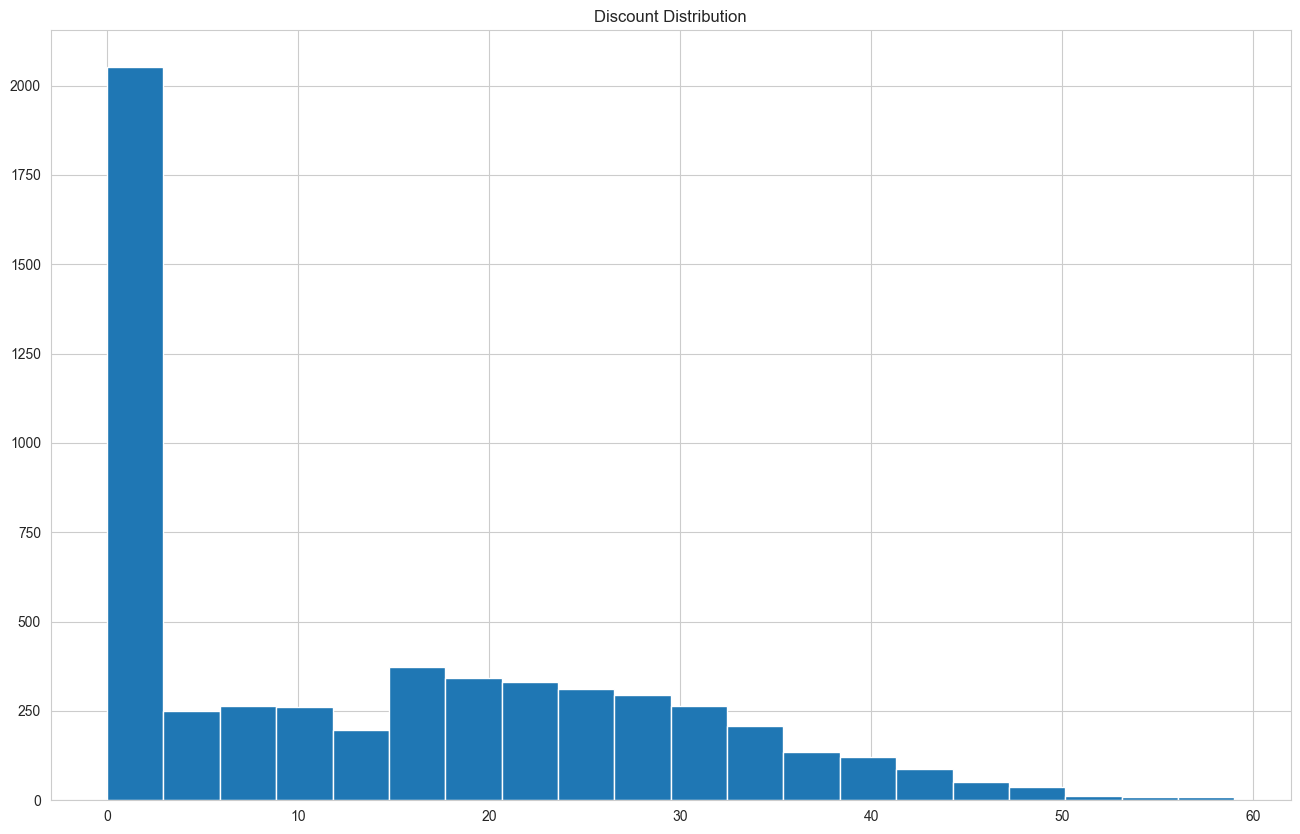

In [21]:
# Discount Distribution
plt.hist(df["Discount_Number"], bins=20)

plt.title("Discount Distribution")

plt.show()

# Customer & Brand Analysis

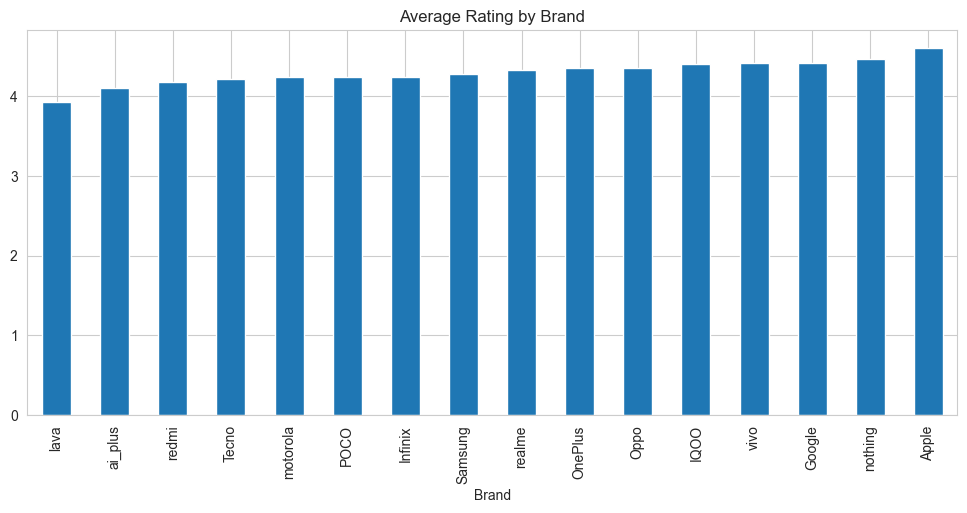

In [22]:
# Average Rating by Brand
rating = df.groupby("Brand")["Rating"].mean().sort_values()

rating.plot(kind="bar", figsize=(12,5))

plt.title("Average Rating by Brand")

plt.show()

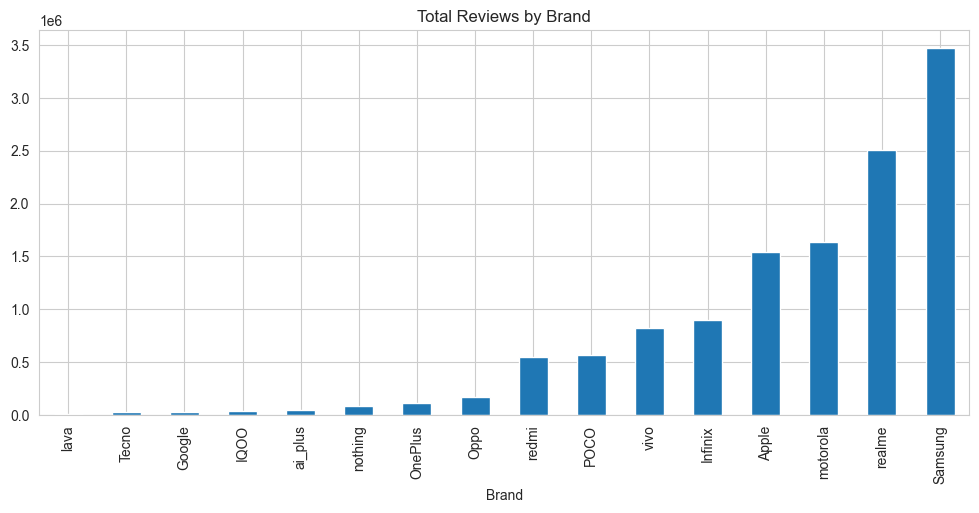

In [23]:
# Most Reviewed Brands
reviews = df.groupby("Brand")["Reviews"].sum().sort_values()

reviews.plot(kind="bar", figsize=(12,5))

plt.title("Total Reviews by Brand")

plt.show()

In [24]:
# Top Rated Smartphones
df.nlargest(10,"Rating")[
    ["Product Name","Brand","Rating"]
]

,Product Name,Brand,Rating
562,"Apple iPhone 7 Plus (PRODUCT) (Red, 256 GB)",Apple,5.0
1866,"OnePlus NORD CE5 (NEXUS BLUE, 256 GB)",OnePlus,5.0
1967,"OnePlus NORD CE5 (NEXUS BLUE, 256 GB)",OnePlus,5.0
2162,"OPPO Find X9 Ultra (Tundra Umber, 512 GB)",Oppo,5.0
3862,"Samsung Galaxy A37 5G (Awesome Lavender, 256 GB)",Samsung,4.9
3863,"Samsung Galaxy A37 5G (Awesome Charcoal, 256 GB)",Samsung,4.9
4438,"Samsung Galaxy A37 5G (Awesome Lavender, 256 GB)",Samsung,4.9
4439,"Samsung Galaxy A37 5G (Awesome Charcoal, 256 GB)",Samsung,4.9
5550,"vivo X300 Ultra (Victory Green, 512 GB)",vivo,4.9
123,"Apple iPhone 17 Pro Max (Deep Blue, 512 GB)",Apple,4.8


In [25]:
# Most Reviewed Smartphones
df.nlargest(10,"Reviews")[
    ["Product Name","Brand","Reviews"]
]

,Product Name,Brand,Reviews
1540,"MOTOROLA Moto E4 Plus (Iron Gray, 32 GB)",motorola,80982
1541,"MOTOROLA Moto E4 Plus (Fine Gold, 32 GB)",motorola,80982
1542,"MOTOROLA Moto E4 Plus (Oxford Blue, 32 GB)",motorola,80982
2749,"realme C2 (Diamond Black, 16 GB)",realme,68328
3244,"realme C2 (Diamond Black, 32 GB)",realme,68328
3245,"realme C2 (Diamond Blue, 32 GB)",realme,68328
3902,"Samsung Galaxy On Nxt (Gold, 64 GB)",Samsung,52915
3910,"Samsung Galaxy On Nxt (Gold, 16 GB)",Samsung,52915
4141,"Samsung Galaxy On Nxt (Black, 64 GB)",Samsung,52915
4478,"Samsung Galaxy On Nxt (Gold, 64 GB)",Samsung,52915


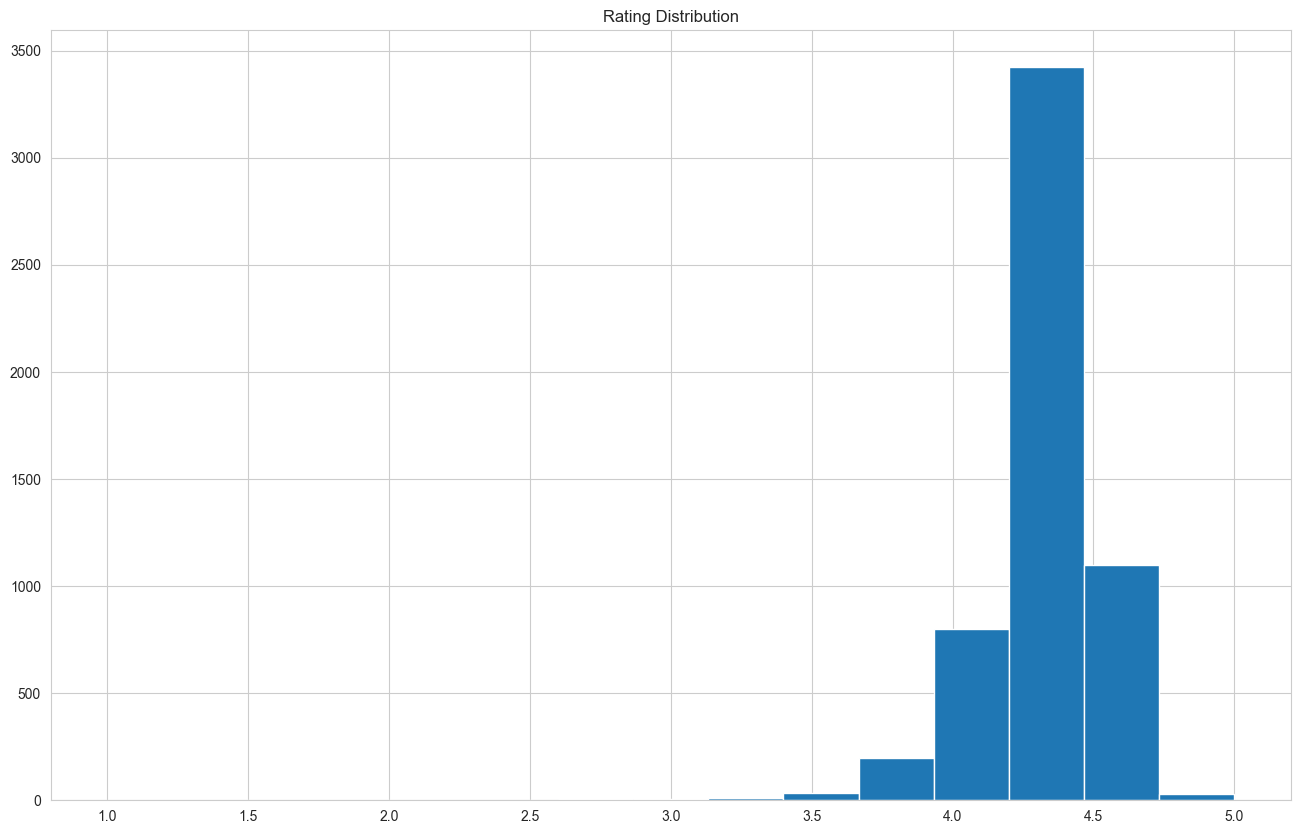

In [26]:
# Rating Distribution
plt.hist(df["Rating"], bins=15)

plt.title("Rating Distribution")

plt.show()

# Business Insights

In [27]:
# Correlation
corr = df[[
    "Current Price",
    "MRP",
    "Discount_Number",
    "Rating",
    "Ratings",
    "Reviews"
]].corr()

print(corr)

                 Current Price       MRP  Discount_Number    Rating   Ratings  \
Current Price         1.000000  0.978634        -0.267795  0.477497 -0.095960   
MRP                   0.978634  1.000000        -0.116030  0.469893 -0.115581   
Discount_Number      -0.267795 -0.116030         1.000000 -0.144015 -0.078572   
Rating                0.477497  0.469893        -0.144015  1.000000  0.141876   
Ratings              -0.095960 -0.115581        -0.078572  0.141876  1.000000   
Reviews              -0.093319 -0.110871        -0.095448  0.109937  0.924770   

                  Reviews  
Current Price   -0.093319  
MRP             -0.110871  
Discount_Number -0.095448  
Rating           0.109937  
Ratings          0.924770  
Reviews          1.000000  


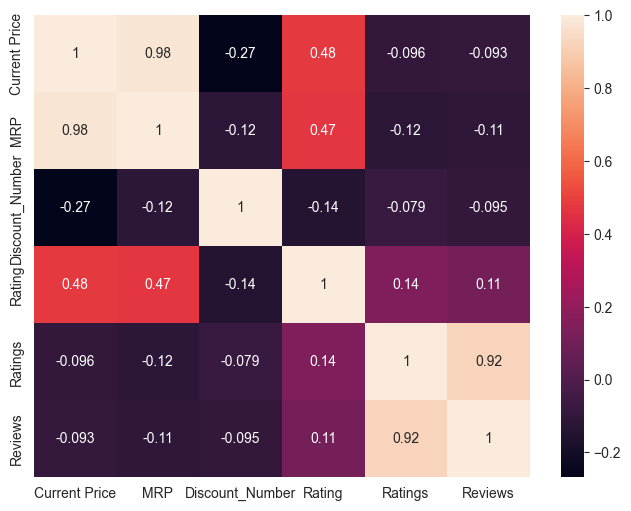

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)

plt.show()

In [29]:
# Top Value Phones
df["Value Score"] = (
    df["Rating"] * df["Discount_Number"]
) / df["Current Price"]

df.nlargest(10,"Value Score")[
    ["Product Name","Brand","Value Score"]
]

,Product Name,Brand,Value Score
2870,"realme C12 (Power Silver, 32 GB)",realme,0.042340
3074,"realme Narzo 20 Pro (Black Ninja, 64 GB)",realme,0.037629
3634,"REDMI A2+ (Sea Green, 64 GB)",redmi,0.033483
1632,"Motorola e32s (Slate Gray, 32 GB)",motorola,0.033195
2871,"realme C12 (Power Blue, 32 GB)",realme,0.033006
2879,"realme C21 (Cross Black, 64 GB)",realme,0.033006
2880,"realme C21 (Cross Blue, 64 GB)",realme,0.033006
2404,"POCO C50 (Royal Blue, 32 GB)",POCO,0.032497
2406,"POCO C50 (Country Green, 32 GB)",POCO,0.032497
2475,"POCO C50 (Royal Blue, 32 GB)",POCO,0.032497


In [30]:
# Premium vs Budget
def segment(price):

    if price < 15000:
        return "Budget"

    elif price < 30000:
        return "Mid Range"

    elif price < 60000:
        return "Premium"

    else:
        return "Ultra Premium"

df["Price Segment"] = df["Current Price"].apply(segment)

In [31]:
df["Price Segment"].value_counts()

Price Segment
Budget           1997
Mid Range        1887
Premium           970
Ultra Premium     753
Name: count, dtype: int64

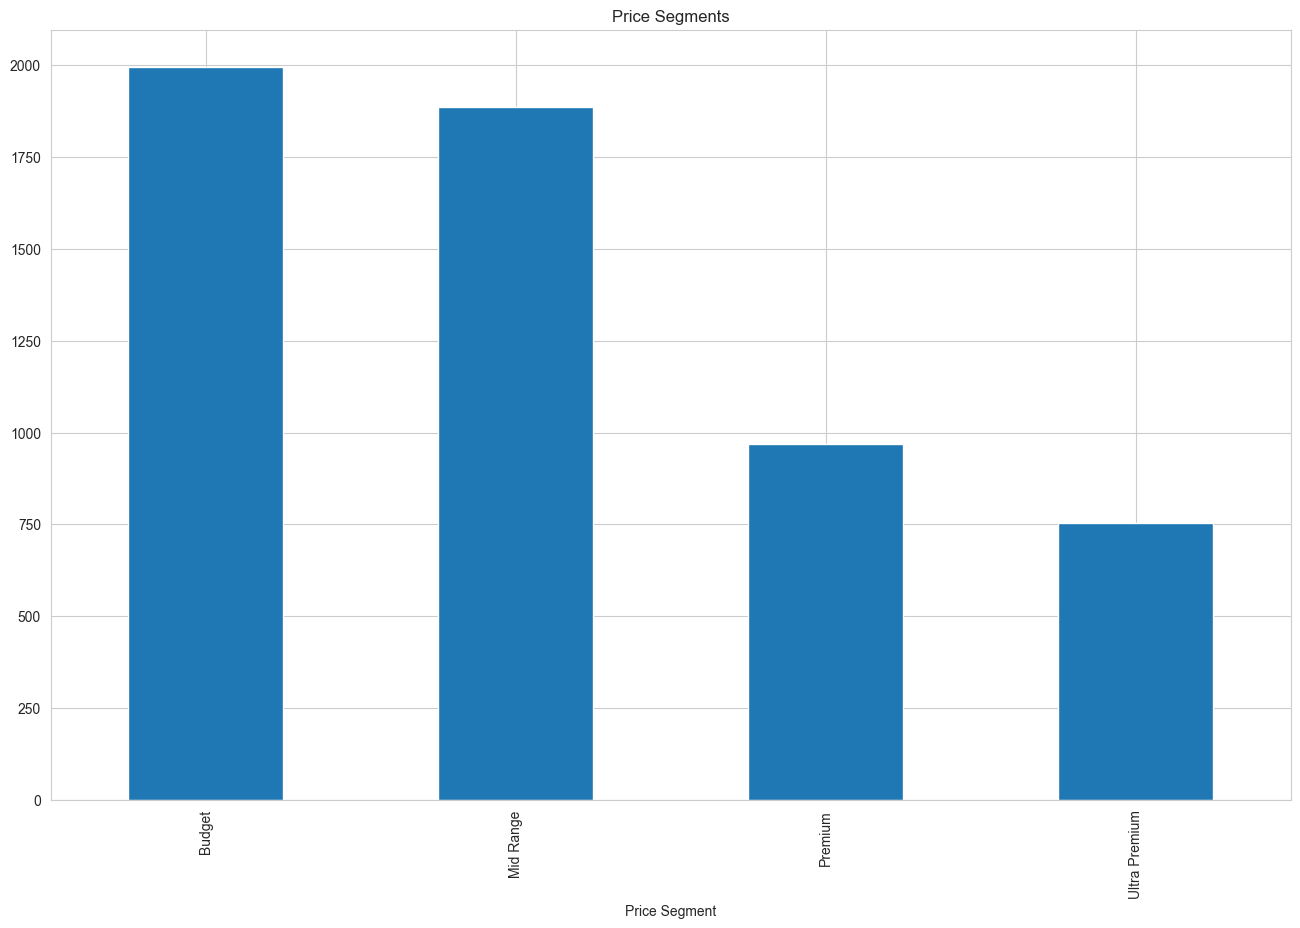

In [32]:
df["Price Segment"].value_counts().plot(kind="bar")

plt.title("Price Segments")

plt.show()